In [38]:
# Week 2: Predicting Researcher-Rated Visual Complexity
# This section investigates whether simple image features (edge density, brightness, and color variation) can predict researcher-assigned visual complexity ratings.

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df = pd.read_csv("features.csv")

df.head()

,image,category,edge_density,brightness,color_var,researcher_complexity,participant_complexity
0,messydesk7.jpg,messydesk,0.077890,101.136589,4335.570978,3,3.0
1,messydesk6.jpg,messydesk,0.137203,104.760084,6056.457666,4,3.8
2,messydesk4.jpg,messydesk,0.210503,100.931705,5855.070950,4,3.6
3,messydesk5.jpg,messydesk,0.210233,151.360417,3667.823877,5,4.4
4,messydesk20.jpg,messydesk,0.125405,148.425892,6162.957314,3,3.6


In [39]:
# Data Quality Check
#The dataset is checked for missing researcher ratings before model training.

print("Missing values in complexity:",
      df["researcher_complexity"].isna().sum())

Missing values in complexity: 0


In [40]:
# Feature Selection
# Three image features are used as predictors: Edge density: amount of visual structure, Brightness: average image intensity, Color variation: RGB variability
X = df[[
    "edge_density",
    "brightness",
    "color_var"
]]

y = df["researcher_complexity"]

from sklearn.model_selection import train_test_split

#Train-Test Split
#The dataset is divided into training (80%) and testing (20%) sets to evaluate model performance on unseen images.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
#Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 9.79,-0.01,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['edge_density','brightness','color_var']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.24
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [42]:
#model predicts complexity from x test based on x train
y_pred = model.predict(X_test)

In [43]:
#calculate mse and r2
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("------------------------")
print("MSE:", mse)
print("R2 score:", r2)

Linear Regression Results
------------------------
MSE: 0.2536525196707228
R2 score: 0.5490621872520485


In [44]:
#Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [45]:
#predict complexity using trained model
rf_pred = rf_model.predict(X_test)

In [46]:
#calculate mse and r2
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MSE:", rf_mse)
print("R2:", rf_r2)

Random Forest Results
---------------------
MSE: 0.3295109375
R2: 0.4142027777777778


In [47]:
# Linear Regression Coefficients
# The regression coefficients indicate how each feature influences predicted visual complexity.
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df)

        Feature  Coefficient
0  edge_density     9.789129
1    brightness    -0.006441
2     color_var    -0.000060


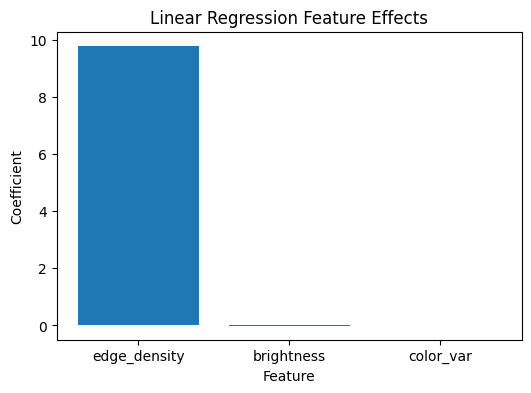

In [48]:
#Bar chart for feature vs regression coefficient
plt.figure(figsize=(6,4))

plt.bar(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.title("Linear Regression Feature Effects")
plt.ylabel("Coefficient")
plt.xlabel("Feature")

plt.show()

In [49]:
#Importances for random forest
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

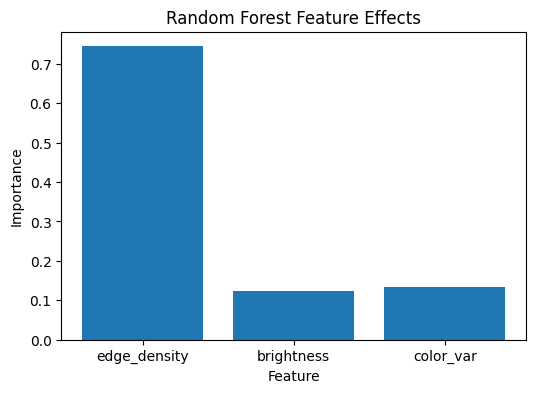

In [50]:
#Bar chart for feature vs importance
plt.figure(figsize=(6,4))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Random Forest Feature Effects")
plt.ylabel("Importance")
plt.xlabel("Feature")

plt.show()

In [51]:
#Random forest feature effects from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

        Feature  Importance
0  edge_density    0.744419
2     color_var    0.132511
1    brightness    0.123070


In [52]:
#Table that compares actual and predicted for each image for linear regression model
results = pd.DataFrame({
    "Image": df.loc[y_test.index, "image"],
    "Category": df.loc[y_test.index, "category"],
    "Actual": y_test,
    "Predicted": y_pred
})

#calculates error
results["Error"] = abs(
    results["Actual"] - results["Predicted"]
)

print(results)

               Image    Category  Actual  Predicted     Error
30      streets9.jpg     streets       4   4.266794  0.266794
0     messydesk7.jpg   messydesk       3   3.088753  0.088753
22     streets20.jpg     streets       4   4.423925  0.423925
31      streets8.jpg     streets       4   4.268867  0.268867
18   messydesk12.jpg   messydesk       4   3.415009  0.584991
28      streets6.jpg     streets       3   3.549135  0.549135
10   messydesk17.jpg   messydesk       3   3.155772  0.155772
70  simpleroom12.jpg  simpleroom       4   2.894469  1.105531
4    messydesk20.jpg   messydesk       3   3.138864  0.138864
12   messydesk14.jpg   messydesk       4   3.238492  0.761508
49    landscape9.jpg   landscape       4   4.402411  0.402411
33     streets13.jpg     streets       5   4.600544  0.399456
67   simpleroom7.jpg  simpleroom       4   3.600510  0.399490
35     streets10.jpg     streets       5   5.015110  0.015110
68   simpleroom3.jpg  simpleroom       2   2.533659  0.533659
45   lan

In [53]:
#Top five worst predictions with greatest error
worst_predictions = results.sort_values(
    by="Error",
    ascending=False
)

print(worst_predictions.head())

               Image    Category  Actual  Predicted     Error
70  simpleroom12.jpg  simpleroom       4   2.894469  1.105531
12   messydesk14.jpg   messydesk       4   3.238492  0.761508
45   landscape14.jpg   landscape       4   4.686924  0.686924
18   messydesk12.jpg   messydesk       4   3.415009  0.584991
28      streets6.jpg     streets       3   3.549135  0.549135


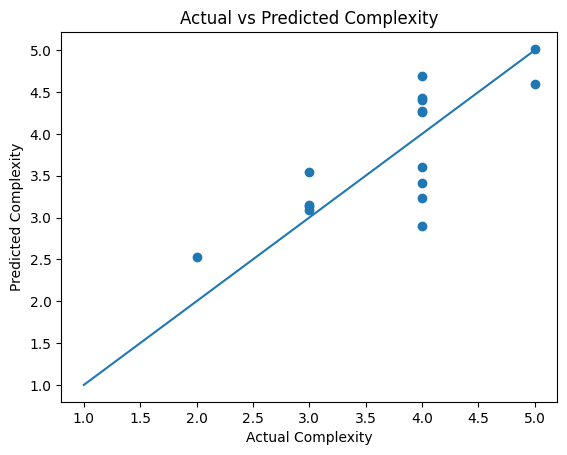

In [54]:
#Predicted vs Actual Ratings
#This scatter plot compares model predictions with researcher ratings for linear regression model.
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Complexity")
plt.ylabel("Predicted Complexity")
plt.title("Actual vs Predicted Complexity")

plt.plot(
    [1,5],
    [1,5]
)

plt.show()

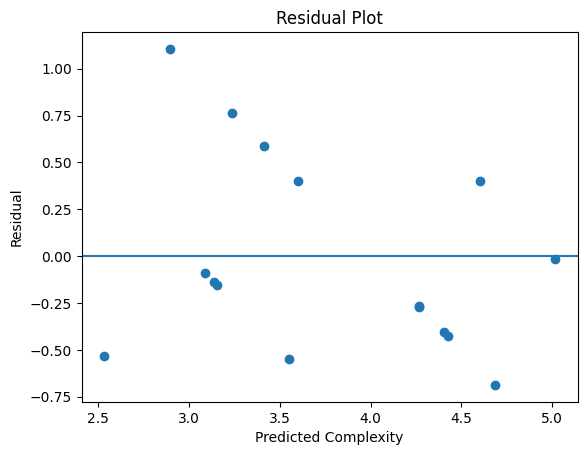

In [55]:
#Residual plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(0)

plt.xlabel("Predicted Complexity")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()